In [12]:
import numpy as np
import wave
from scipy.io import wavfile
import librosa
import matplotlib.pyplot as plt
from scipy.signal import firwin
from scipy import signal
from IPython.display import Audio
from math import gcd
from scipy.signal import firwin, lfilter, filtfilt
from scipy.signal import resample_poly
from scipy.interpolate import CubicSpline
from scipy.signal import hilbert

<class 'numpy.ndarray'>
int16
Sample rate: 44100

Data shape: (606084,)


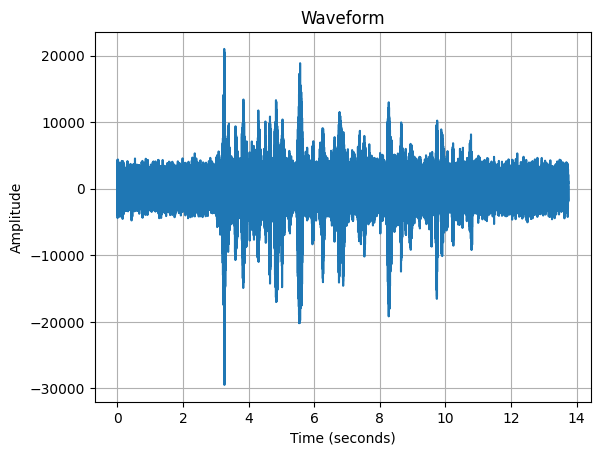

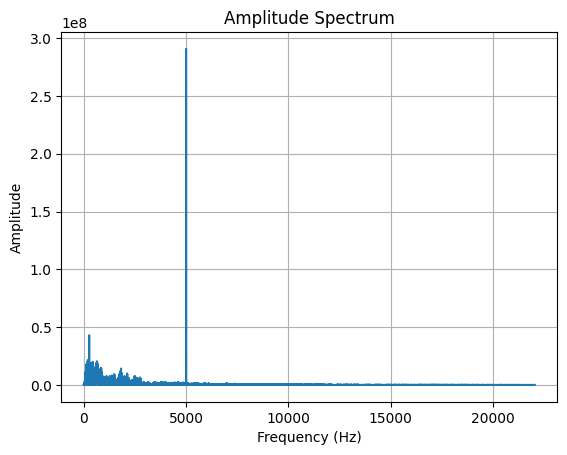

In [13]:
path_to_audio = r"D:\prednasky\ZSI\veta.wav"


sample_rate, data = wavfile.read(path_to_audio)
print(type(data))
print(data.dtype)

print(f"Sample rate: {sample_rate}\n")
print(f"Data shape: {data.shape}")

time = np.linspace(0, len(data) / sample_rate, num=len(data))

plt.figure()
plt.grid(True)
plt.plot(time, data)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()


fft_result = np.fft.fft(data)

frequencies = np.fft.fftfreq(len(data), d=1/sample_rate)

half = len(frequencies) // 2
frequencies = frequencies[:half]
magnitude = np.abs(fft_result[:half])

plt.figure()
plt.grid(True)
plt.plot(frequencies, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.show()


max_val = np.max(np.abs(data))
if max_val > 0:
    normalized_data = data / max_val
display(Audio(data, rate=sample_rate))

# Funk for Max, Min

In [14]:
def find_local_extrema(signal):
    maxima = []
    minima = []

    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            maxima.append(i)

        elif signal[i] < signal[i - 1] and signal[i] < signal[i + 1]:
            minima.append(i)

    return np.array(maxima), np.array(minima)

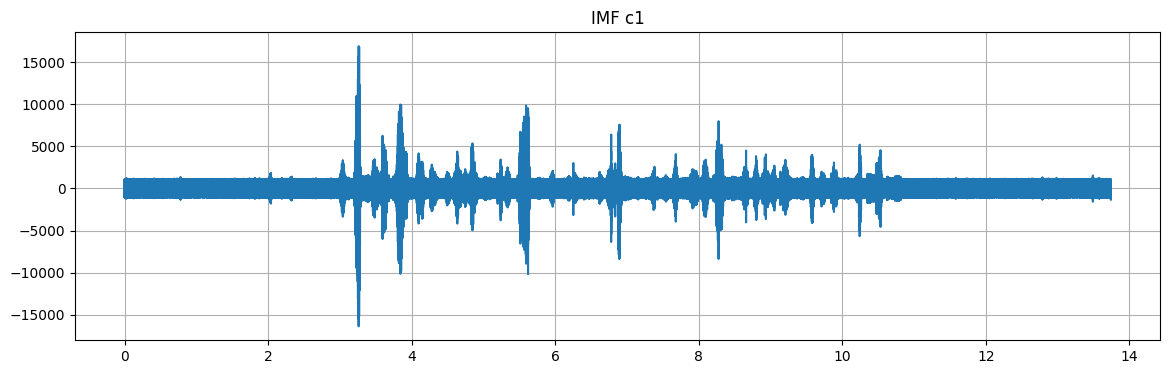

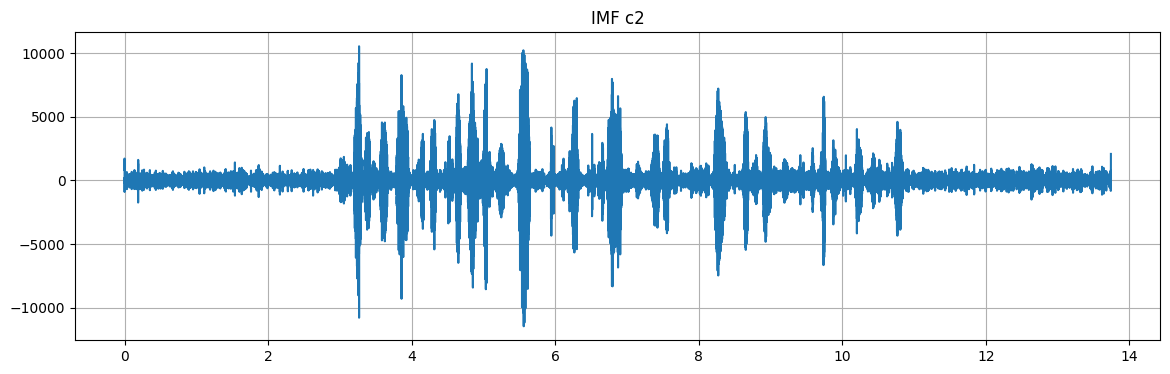

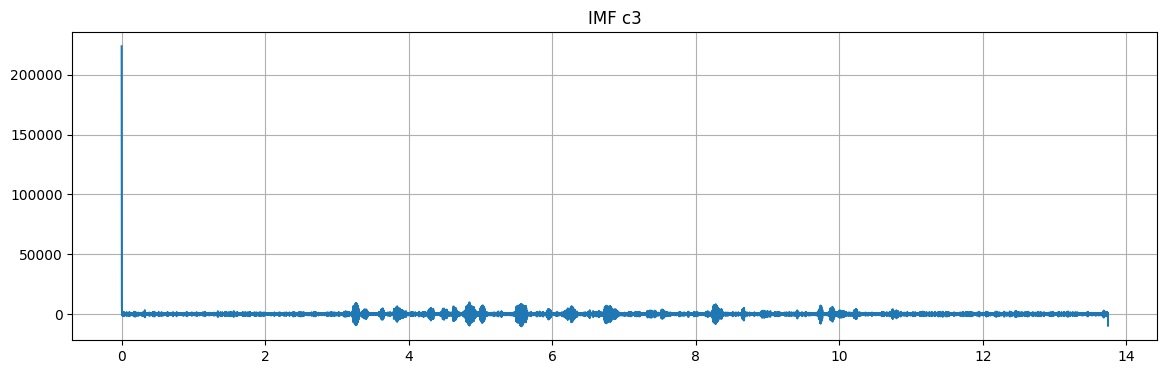

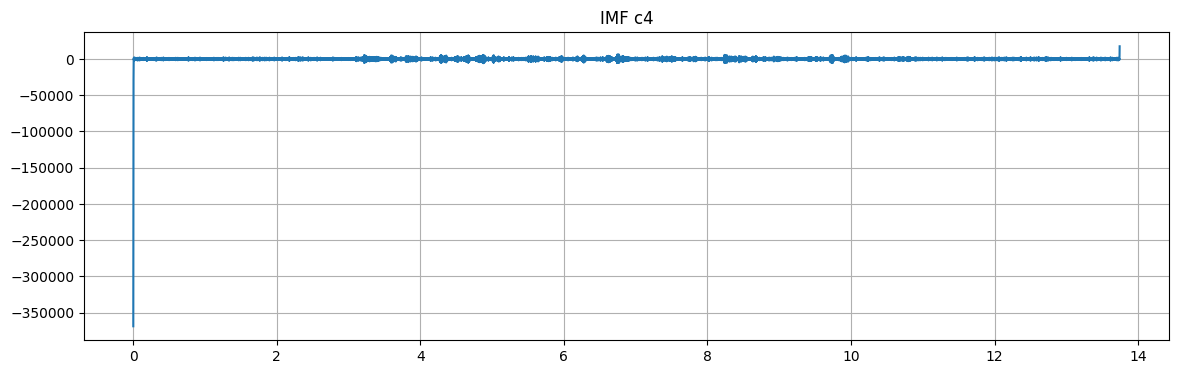

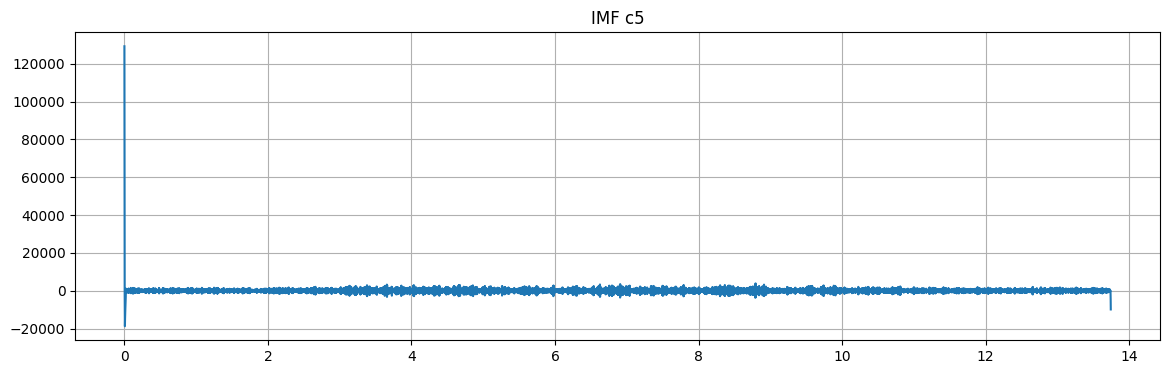

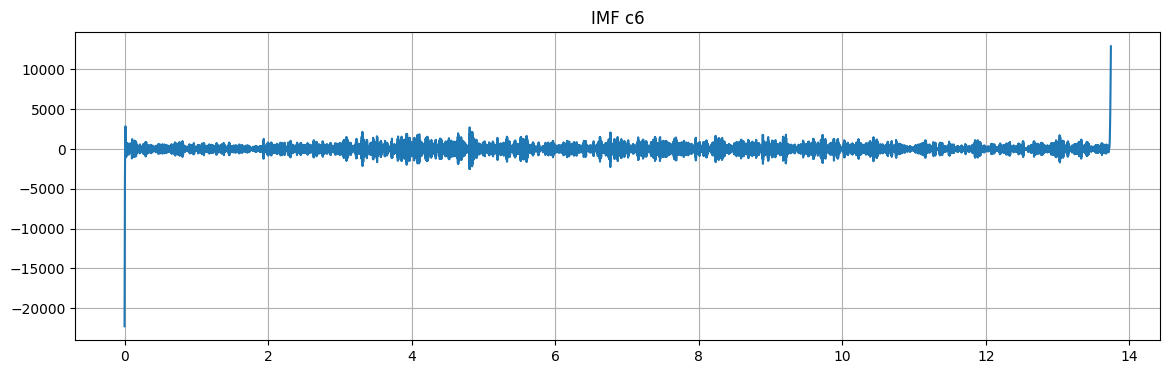

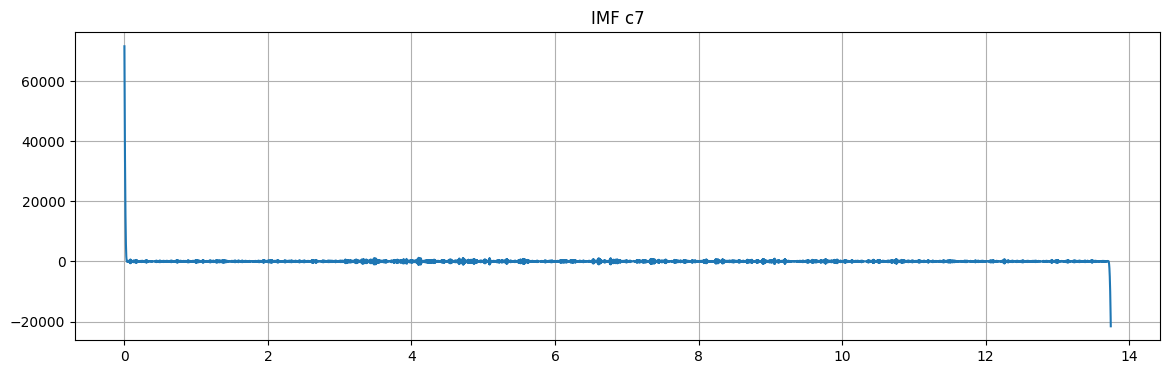

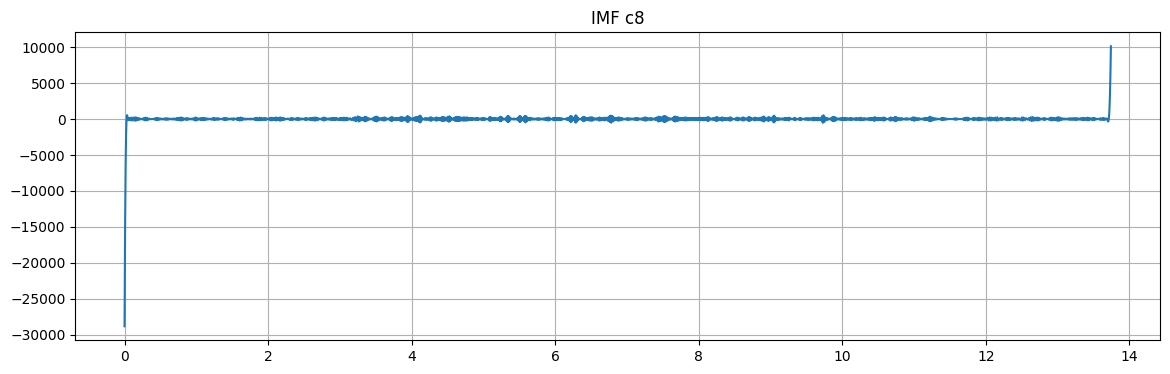

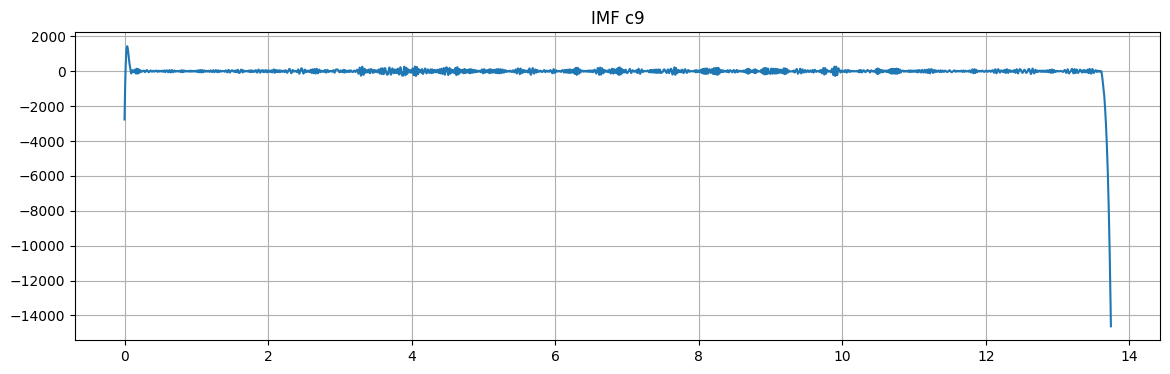

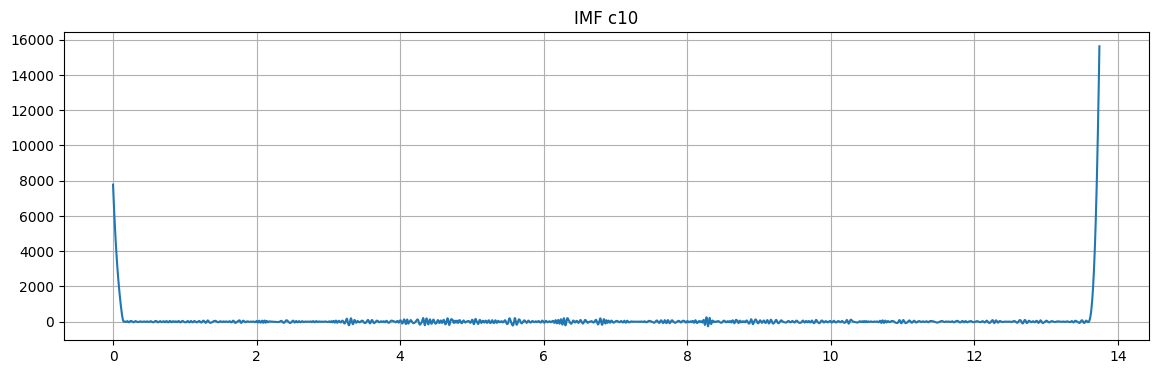

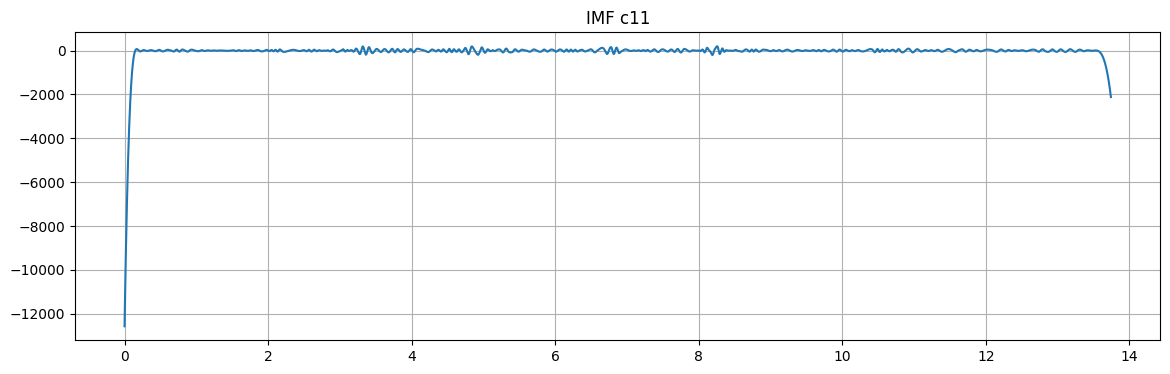

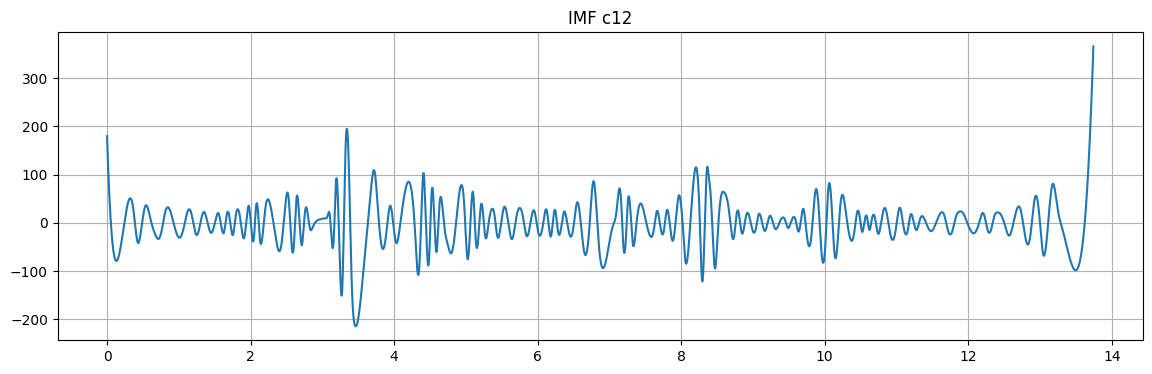

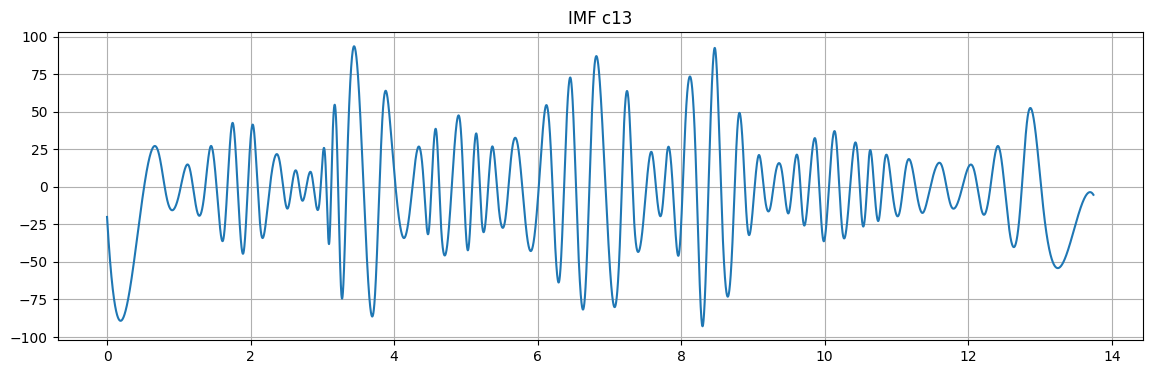

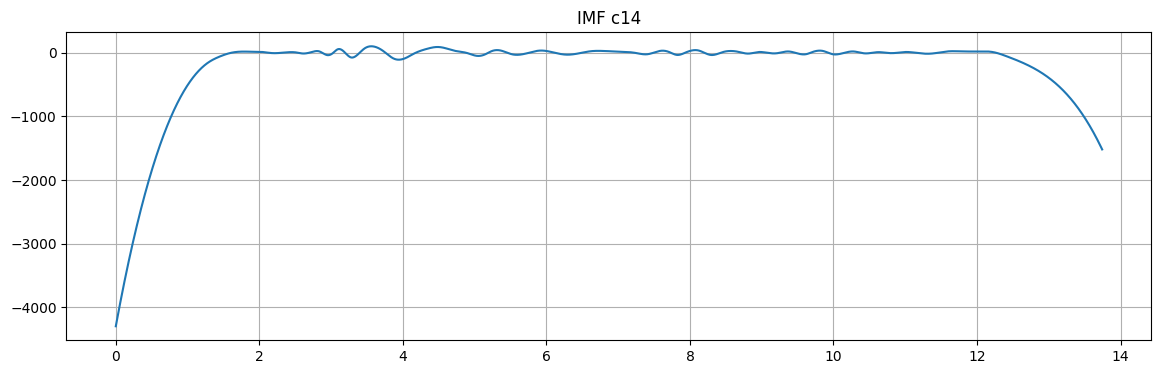

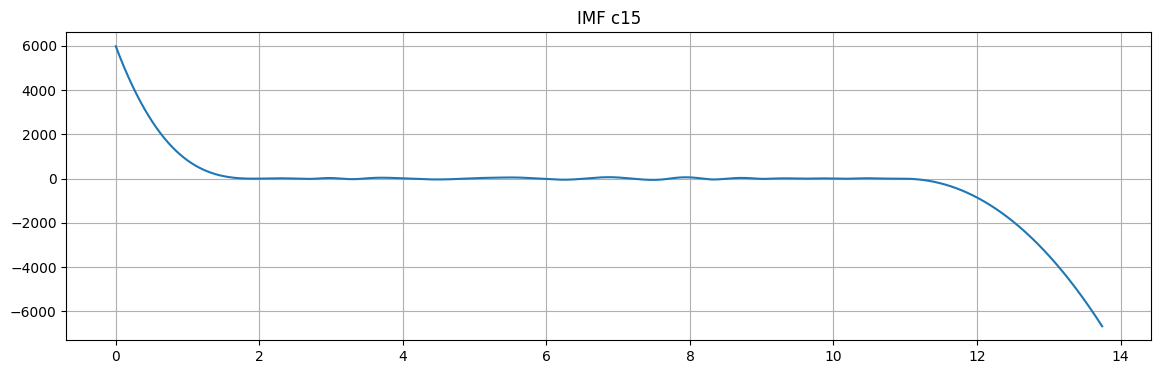

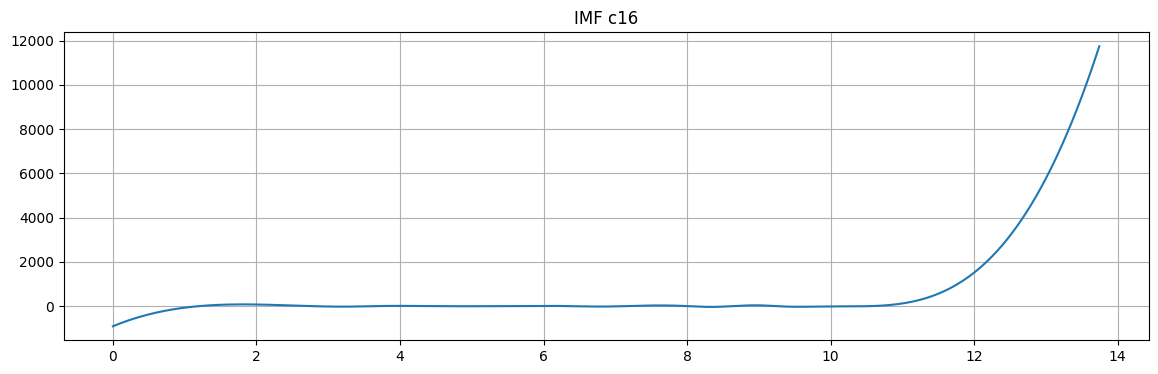

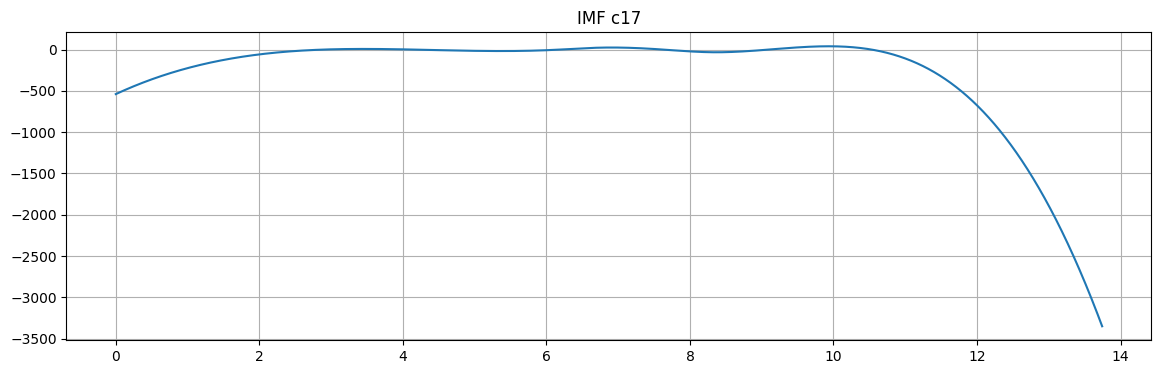

In [15]:
MAX_ITER = 35


MAX_IMF = 20

signal = data.copy()

imfs = []

for c in range(MAX_IMF):

    h = signal.copy()

    for i in range(MAX_ITER):

        maxima, minima = find_local_extrema(h)

        upper = CubicSpline(time[maxima], h[maxima])
        lower = CubicSpline(time[minima], h[minima])

        upper_env = upper(time)
        lower_env = lower(time)

        mean = (upper_env + lower_env) / 2


        h = h - mean

    imfs.append(h)
    plt.figure(figsize=(14,4))
    plt.plot(time, h)
    plt.title(f"IMF c{c+1}")
    plt.grid(True)
    plt.show()

    signal = signal - h

    maxima, minima = find_local_extrema(signal)

    if len(maxima) < 2 or len(minima) < 2:
        break

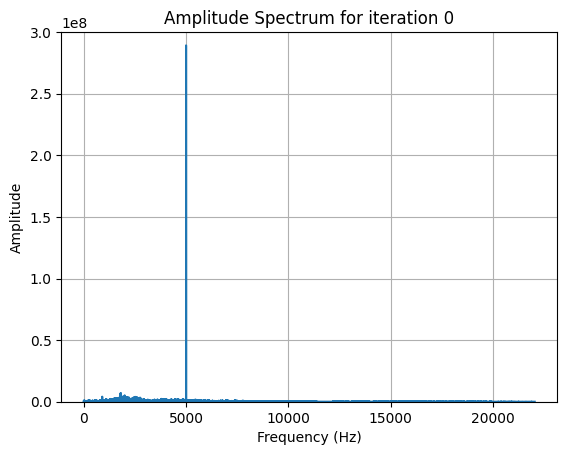

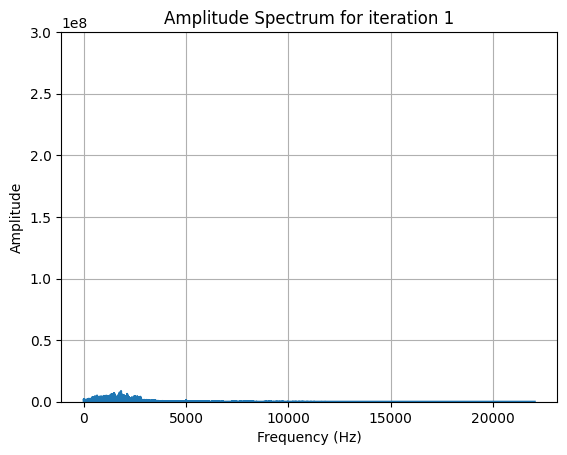

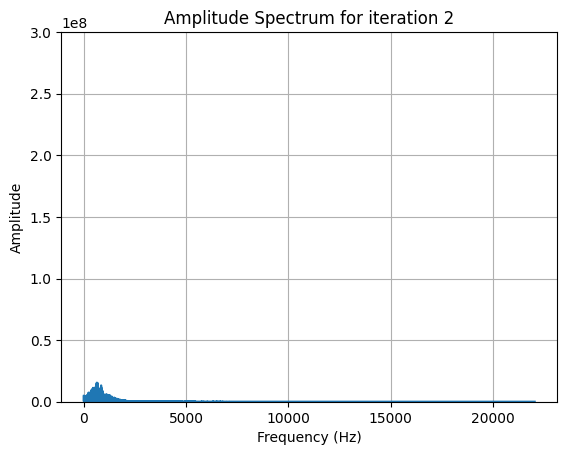

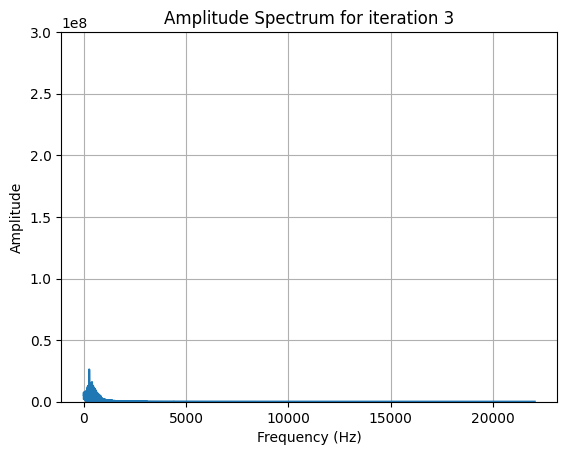

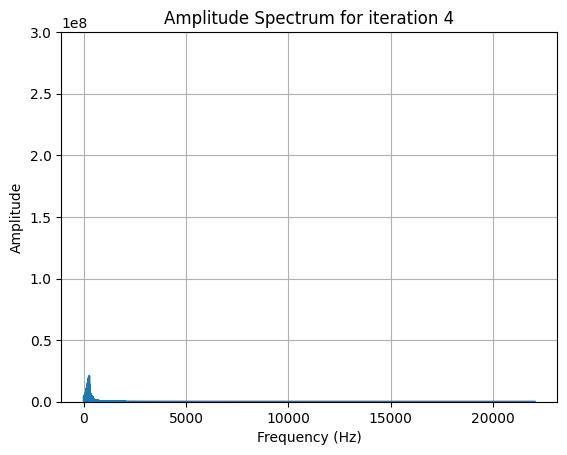

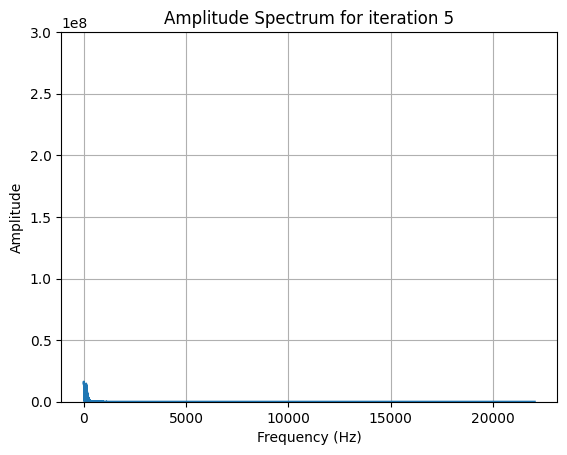

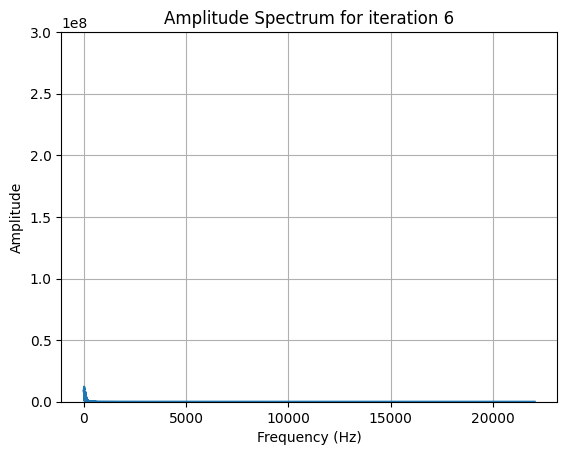

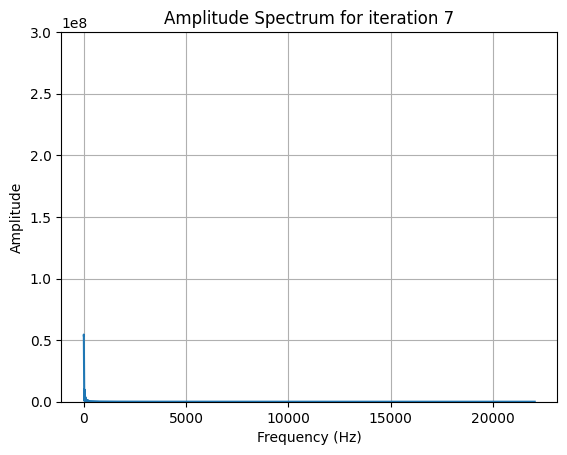

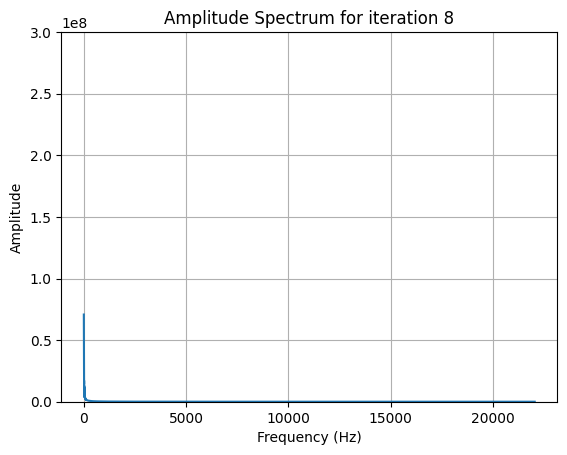

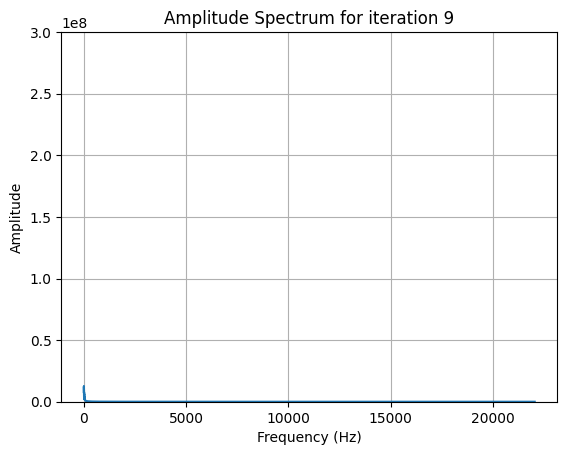

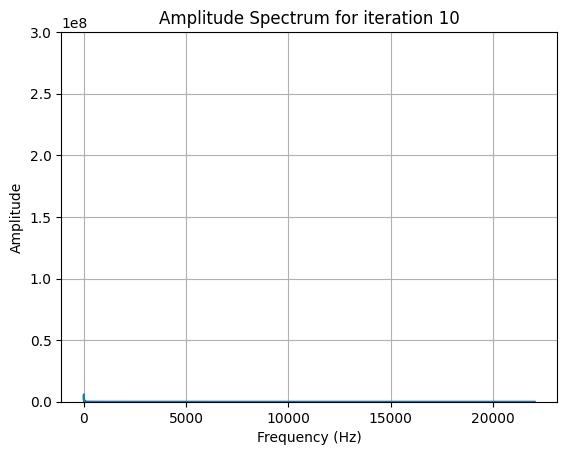

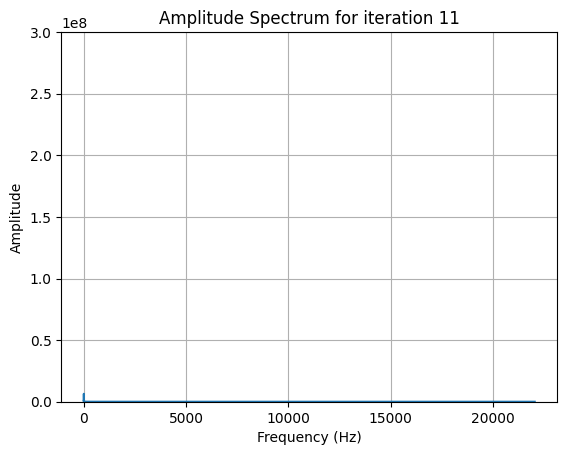

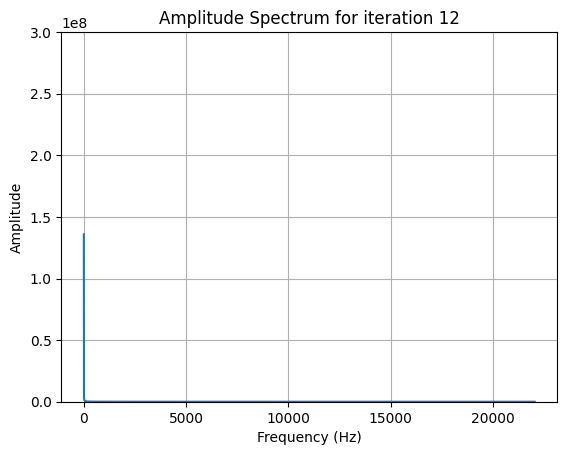

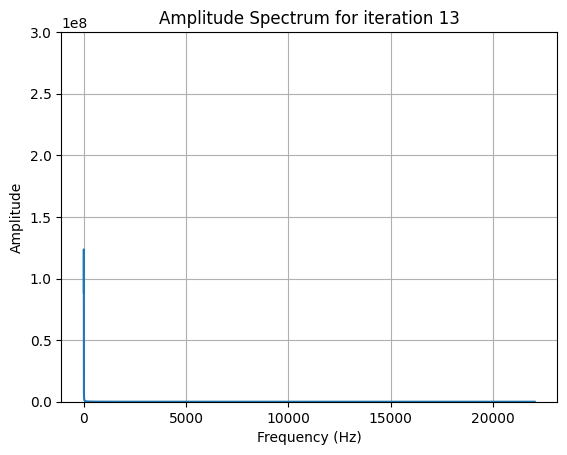

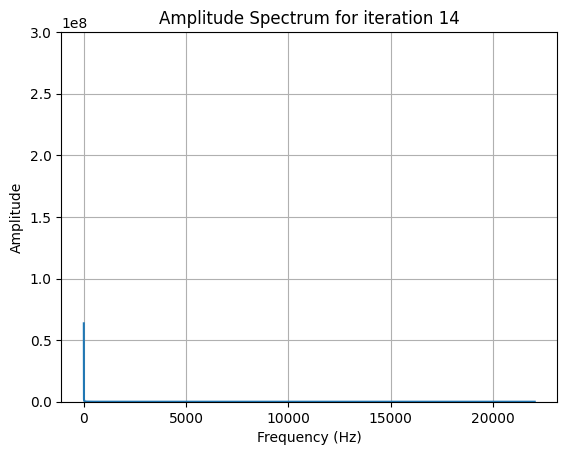

In [5]:
for i, imf in enumerate(imfs):

    fft_result = np.fft.fft(imf)
    frequencies = np.fft.fftfreq(len(imf), d=1/sample_rate)

    half = len(frequencies) // 2
    frequencies = frequencies[:half]
    magnitude = np.abs(fft_result[:half])

    plt.figure()
    plt.grid(True)
    plt.plot(frequencies, magnitude)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    ylim = 3e8

    plt.ylim(0, ylim)
    plt.title(f"Amplitude Spectrum for iteration {i}")
    plt.show()

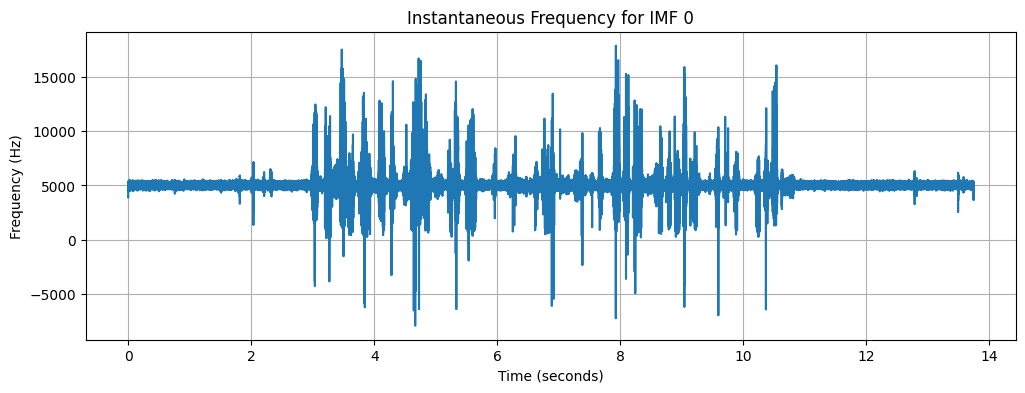

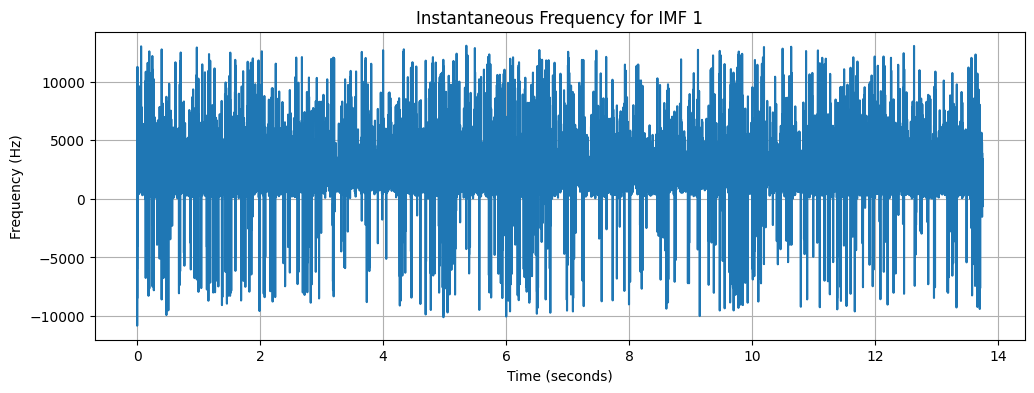

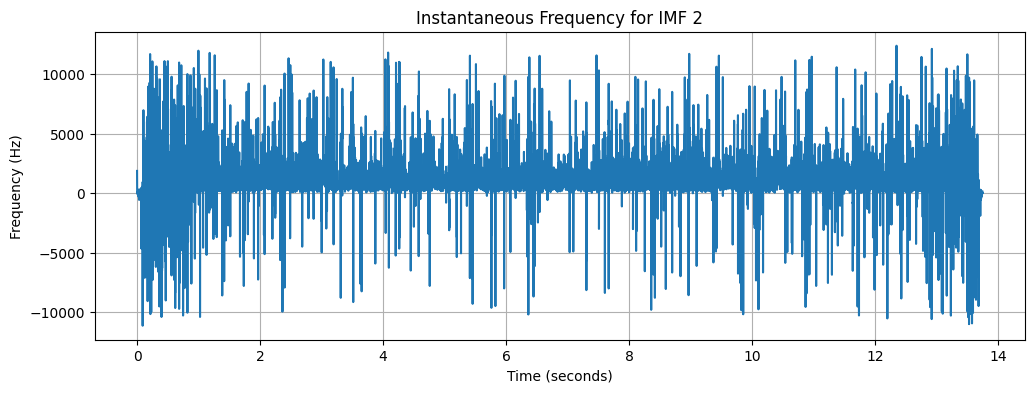

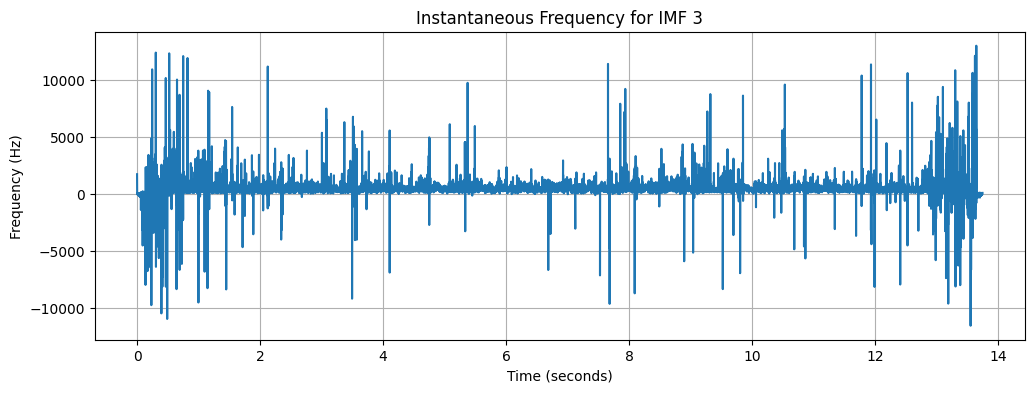

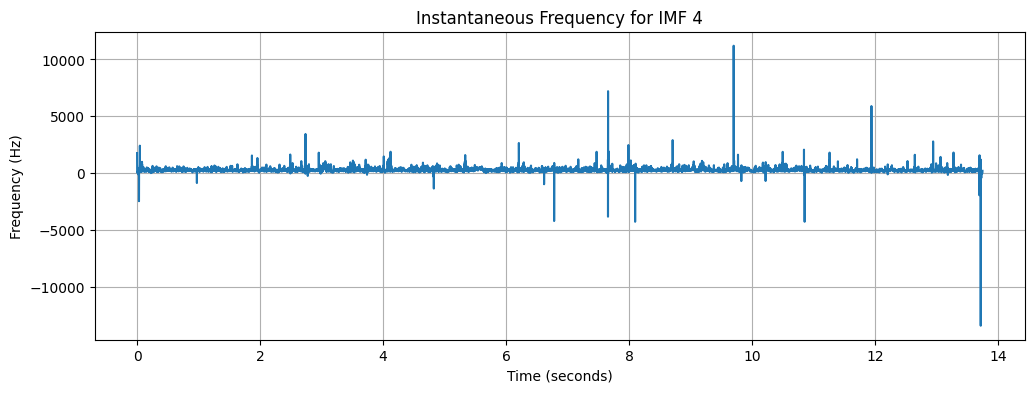

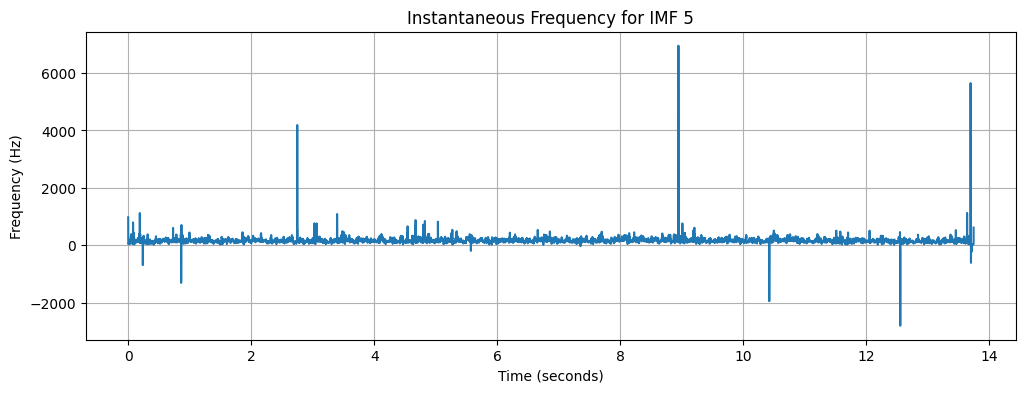

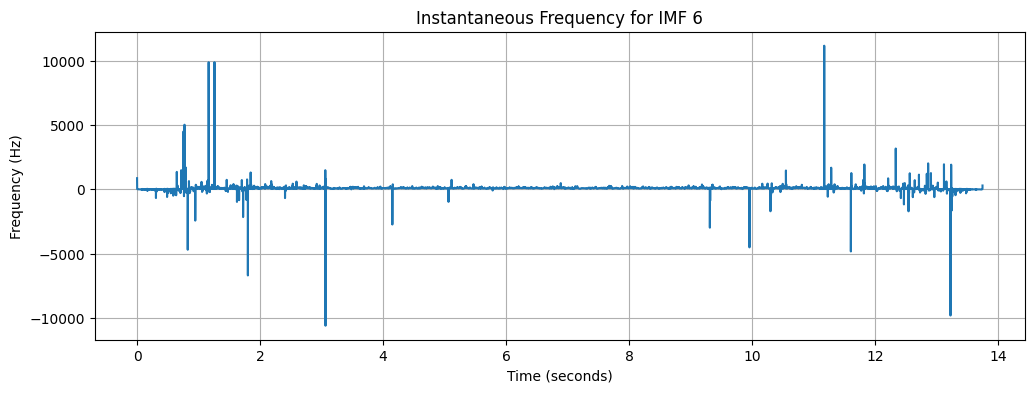

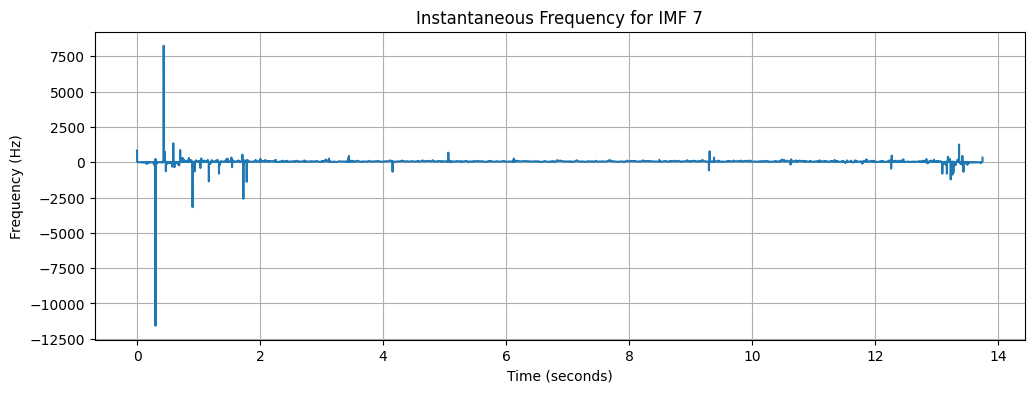

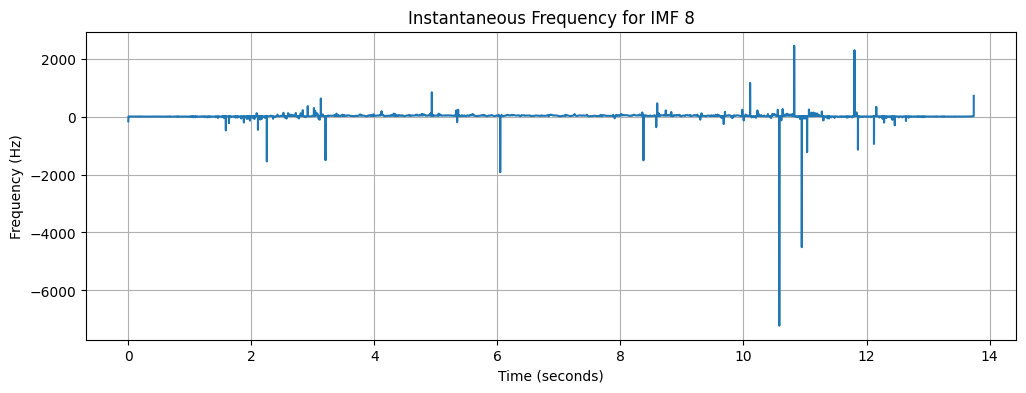

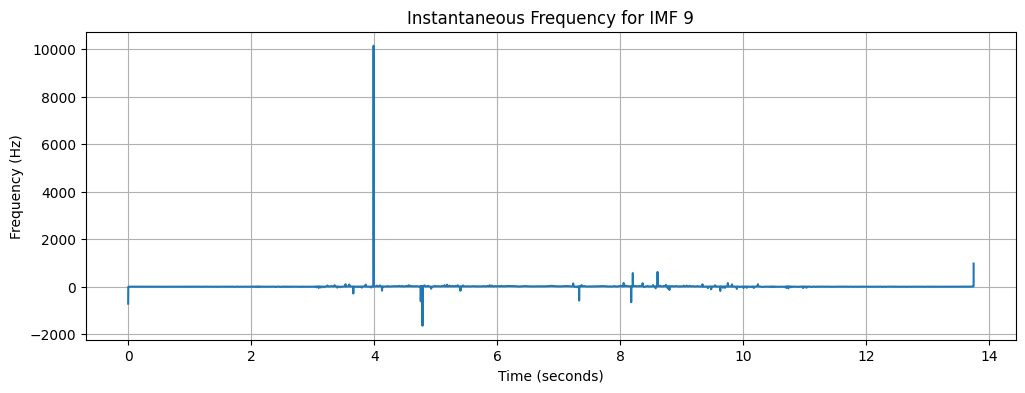

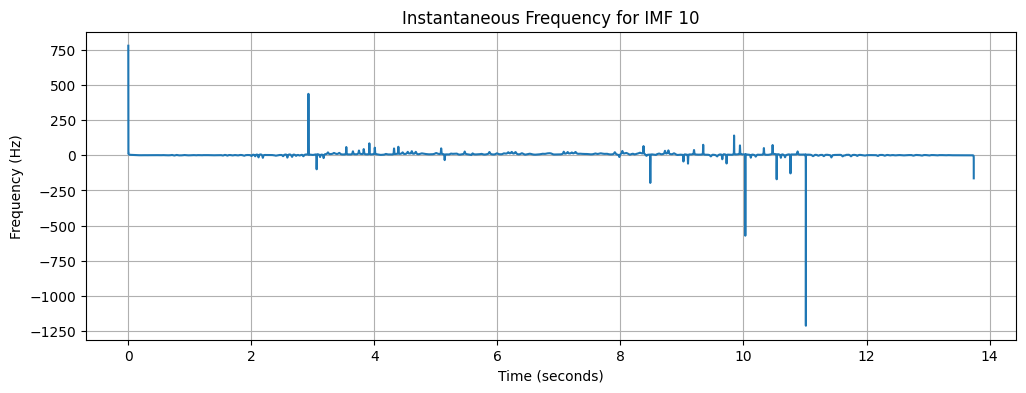

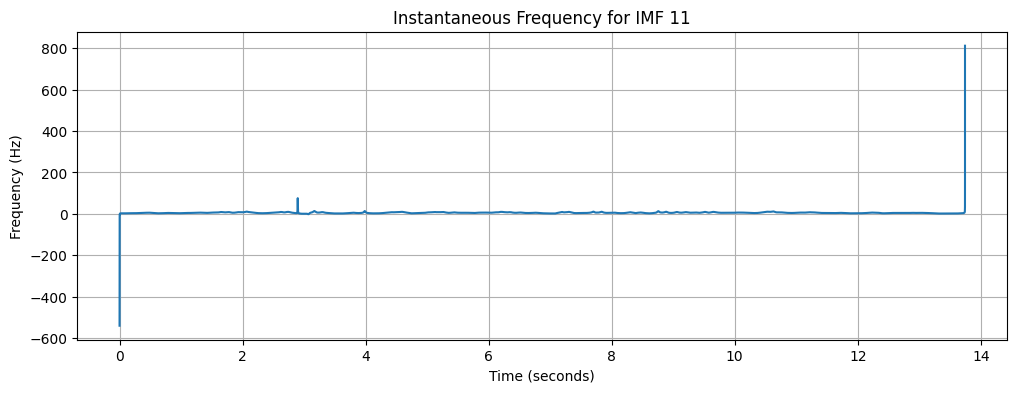

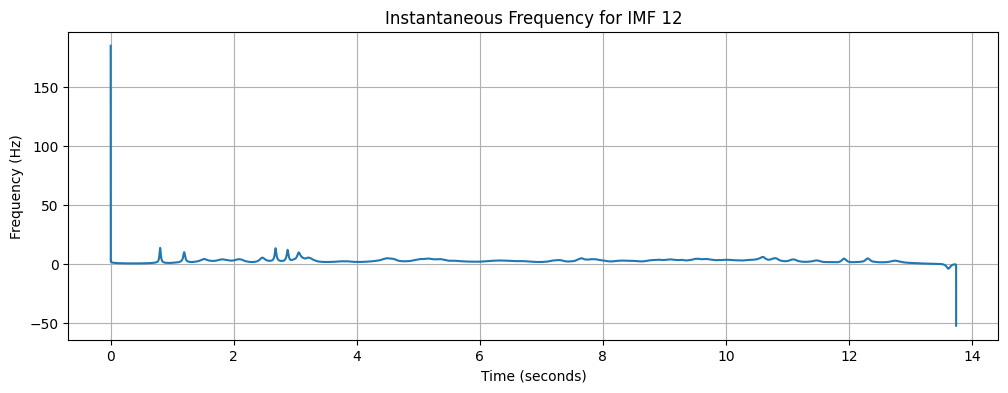

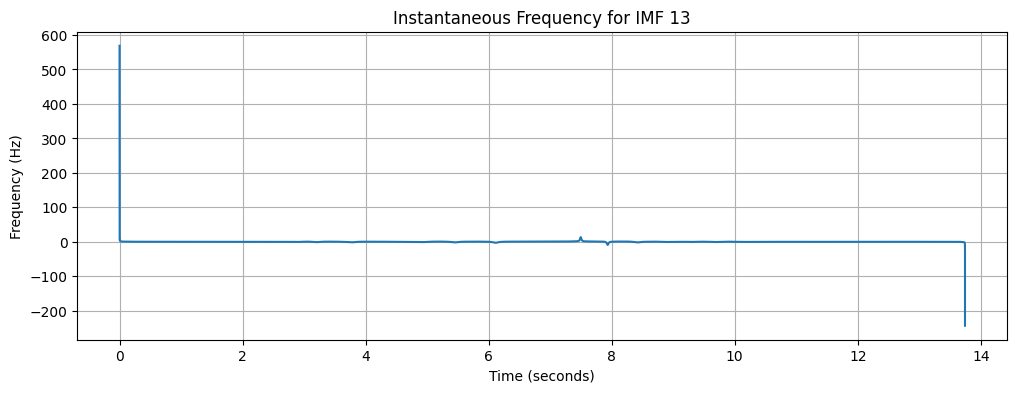

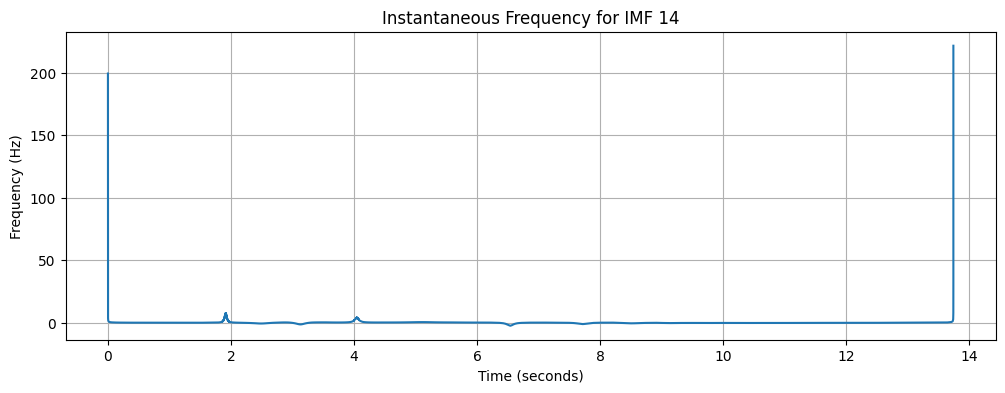

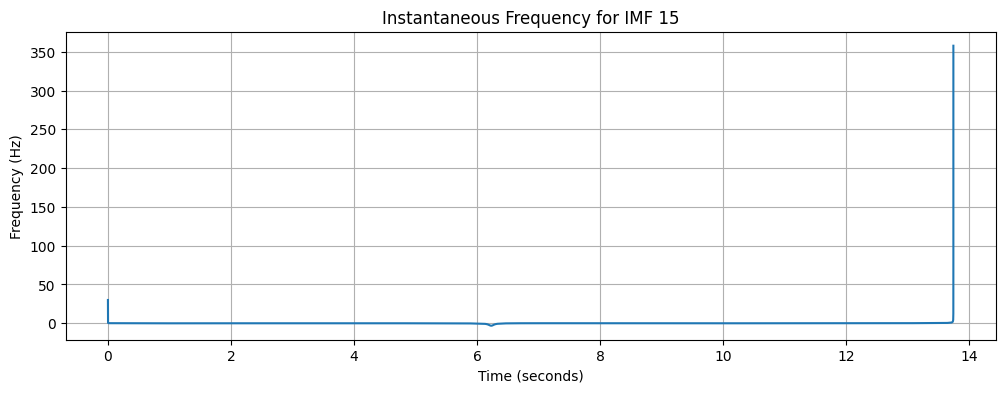

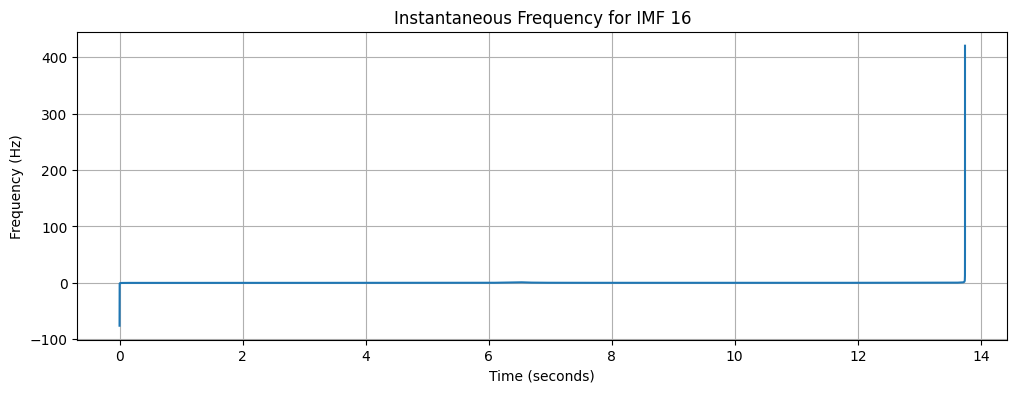

In [17]:
for i, imf in enumerate(imfs):

    analytic_signal = hilbert(imf)

    instantaneous_phase = np.unwrap(np.angle(analytic_signal))

    instantaneous_frequency = (
            np.gradient(instantaneous_phase) * sample_rate / (2 * np.pi)
    )

    plt.figure(figsize=(12, 4))
    plt.grid(True)
    plt.plot(time, instantaneous_frequency)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Instantaneous Frequency for IMF {i}")
    plt.show()